## Optical signal propagation during an earthquake
The other demos demonstrate signal transmission and propagation, and earthquake modelling.
This notebook brings those two together, modelling the propagation of a signal during an earthquake.

We start by defining the system parameters as usual.

In [1]:
from configparser import ConfigParser

parameters = ConfigParser()

parameters['FIBRE'] = {
    'section_length':    '100',  # Correlation length in km
    'path_coordinates':  '[ \
        [-71.62043502747198,-33.04554123247811], \
        [-72.67487428049728,-31.85146566557725], \
        [-79.64986933934534,-18.45381377577717], \
        [-84.14986615150535,-11.503333845984299], \
        [-85.4998651951533,-6.616650693475355], \
        [-85.94986487636929,0.568578852526193], \
        [-87.06475643430802,5.534179292238662], \
        [-92.69986009460932,9.52441134501949], \
        [-98.09985626920157,12.615395567393394], \
        [-104.39985180622544,16.10232559580297], \
        [-108.44984893716946,18.678647022154717], \
        [-114.29984479297735,22.469443964829516], \
        [-118.79984160513736,27.76358852605777], \
        [-119.6998409675696,31.286738814391754], \
        [-119.24984128635361,32.8123187832876], \
        [-118.79984160513764,33.75276987113061], \
        [-118.41596126184768,33.91992001851462] \
    ]',                          # Estimate coordinates of the Curie cable, taken from https://www.submarinecablemap.com/api/v3/cable/cable-geo.json
    'PMD_parameter':     '0.1',  # Polarisation mode dispersion parameter in ps / (km ^ 0.5)
    'realisation_count': '1000', # Number of fibre realisations to simulate simultaneously
    'photoelasticity':   '0.1',  # Photoelasticity, which relates material strain to optical strain
    'group_delay':       '4.9e6' # Group delay in ps / km
}

parameters['TRANSCEIVER'] = {
    'constellation':    'QPSK',  # The symbol constellation to use
    'power':            '2',     # Transmission power in dBm
    'baud_rate':        '1e11',  # Baud rate in symbols / s
    'pulse':            'RRCOS', # Pulseshape, can be SINC or RRCOS, or define your own using the Pulse class
    'pulse_parameter':  '0.5',   # Parameter to pass to the pulse constructor. For a RRCOS pulse, this is the rolloff factor
    'upsample_factor':  '4',     # Samples per symbol
    'filter':           'RRCOS', # Antialiasing (matched) filter
    'filter_parameter': '0.5'    # Same
}

parameters['SIGNAL'] = {
    'batch_size':   '1', # The number of signals to transmit simultaneously
    'symbol_count': '25' # The number of symbols to transmit per signal
}

parameters['EARTHQUAKE'] = {
    'event': 'GCMT:C201002270634A', # A historic earthquake event, structured <catalog>:<identifier> (e.g. from https://www.globalcmt.org/)
    'model': 'ak135f_5s'             # Earth model for Syngine to use from https://ds.iris.edu/ds/products/syngine/#earth
}

Now, we create the transceiver, fibre and earthquake.

In [2]:
from tremor_waveplate_toolbox import Transmitter, Fibre, Receiver, Earthquake

transmitter = Transmitter(parameters)
fibre = Fibre(parameters)
receiver = Receiver(parameters)
earthquake = Earthquake(parameters)

ConnectionError: HTTPConnectionPool(host='service.iris.edu', port=80): Max retries exceeded with url: /irisws/syngine/1/query?model=ak135f_5s&eventid=GCMT%3AC201002270634A&format=miniseed&receiverlatitude=0.0&receiverlongitude=0.0 (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x76855fd86ae0>: Failed to resolve 'service.iris.edu' ([Errno -2] Name or service not known)"))

Next, we obtain the strain imposed on the fibre by the earthquake over time

In [3]:
earthquake_time, _, _, _, _, strain = earthquake(fibre, verbose = True)

Requesting seismograms: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97/97 [03:21<00:00,  2.08s/it]


We specify the moment at which transmission begins, relative to the start of the earthquake measurement.
As strain changes slowly with respect to the optical sample rate, we assume strain to be constant from this moment until the transmission end.
Signal time is corrected for the mean group delay, so we have to transform the time axis to obtain the correct corresponding strain.

In [11]:
earthquake_time_PMD = earthquake_time[:, None] - parameters.getfloat('FIBRE', 'group_delay') * fibre.section_centre_positions[None] * 1e-12 # [T, 1] - [1, S]

start_time = 60 # Start transmission one minute after the earthquake
start_time_PMD = start_time - beta1 * z # Start time relative to mean group delay
start_strain = # Strain during transmission


In [58]:
print(earthquake_time)

[0.00000e+00 2.50000e-01 5.00000e-01 ... 3.87925e+03 3.87950e+03
 3.87975e+03]


/tmp/ipykernel_8706/2287728406.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


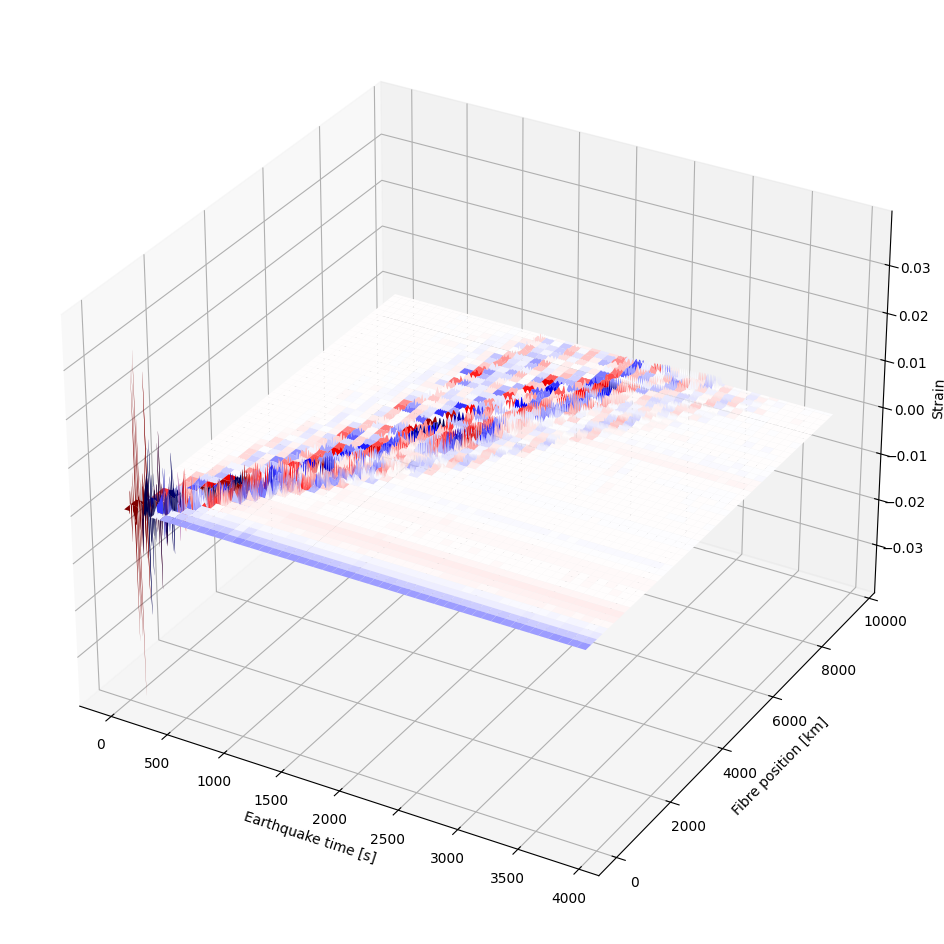

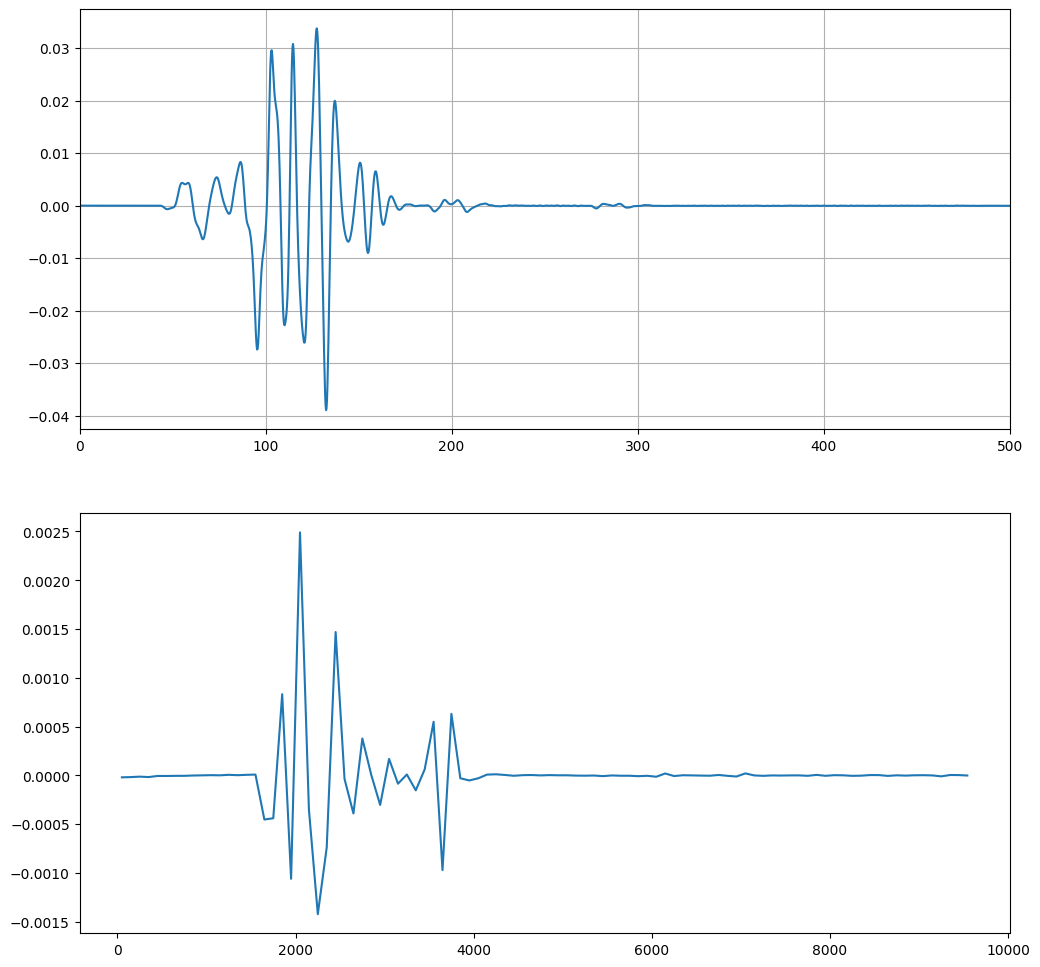

In [57]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (12, 12), subplot_kw = {'projection': '3d'})

ax.plot_surface(
    earthquake_time[None],
    fibre.section_centre_positions[:, None],
    strain,
    cmap = 'seismic',
    vmin = -1e-4,
    vmax = 1e-4
)
ax.set_xlabel("Earthquake time [s]")
ax.set_ylabel("Fibre position [km]")
ax.set_zlabel("Strain")

fig, axes = plt.subplots(2, figsize = (12, 12))

axes[0].plot(
    earthquake_time,
    strain[0]
)
axes[0].grid()
axes[0].set_xlim([0, 500])

axes[1].plot(
    fibre.section_centre_positions,
    strain[:, 3000]
)

fig.show()